<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Outliers**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis or EDA. 
You will explore the distribution of key variables and focus on identifying outliers in this lab.


## Objectives


In this lab, you will perform the following:


-  Analyze the distribution of key variables in the dataset.

-  Identify and remove outliers using statistical methods.

-  Perform relevant statistical and correlation analysis.


#### Install and import the required libraries


In [ ]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<h3>Step 1: Load and Explore the Dataset</h3>


Load the dataset into a DataFrame and examine the structure of the data.


In [ ]:
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

#Create the dataframe
df = pd.read_csv(file_url)

#Display the top 10 records
df.head()


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file = r"C:\Users\21650\Downloads\survey_data.csv"

#Create the dataframe
df = pd.read_csv(file)

#Display the top 10 records
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 2: Plot the Distribution of Industry</h3>


Explore how respondents are distributed across different industries.

- Plot a bar chart to visualize the distribution of respondents by industry.

- Highlight any notable trends.


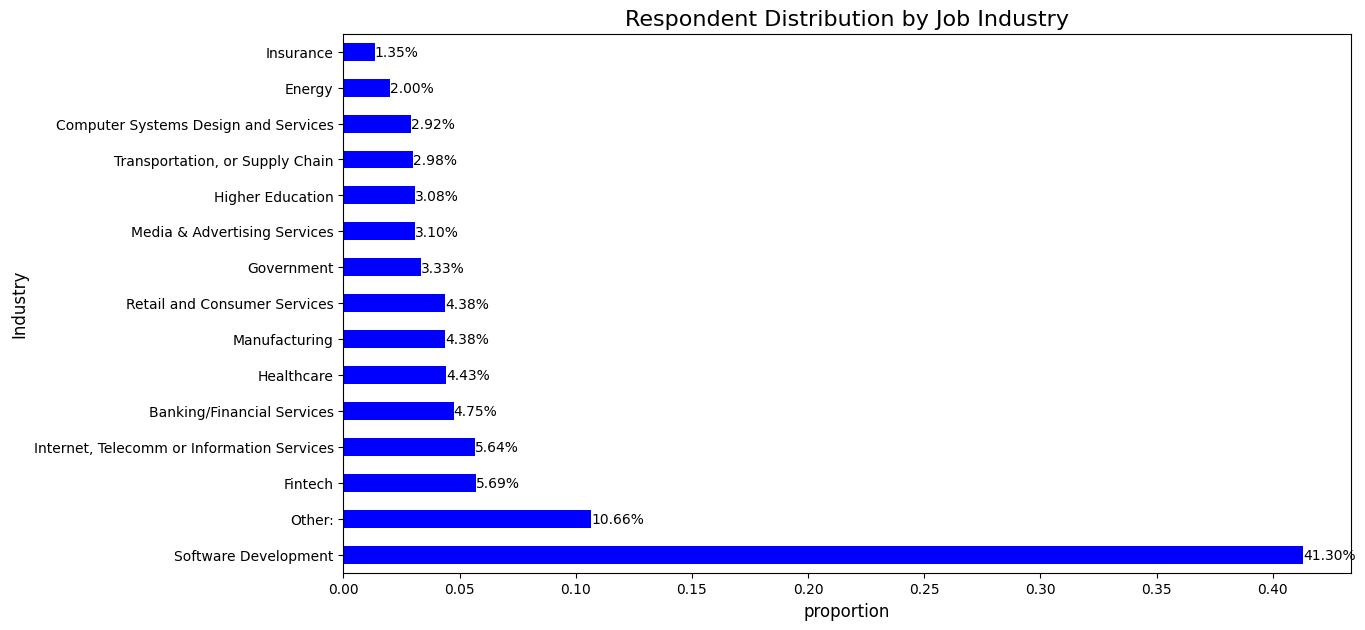

In [3]:
##Write your code here
branch_count=df["Industry"].value_counts(normalize=True).reset_index()
fig,ax=plt.subplots(figsize=(13,7))
branch_count["proportion"].plot(kind="barh",ax=ax,color="blue")
ax.set_yticklabels(branch_count["Industry"].values)
for index, value in enumerate(branch_count["proportion"]):
    plt.annotate("{:.2%}".format(value),xy=[value,index-.13])
plt.title("Respondent Distribution by Job Industry",fontsize=16)
plt.xlabel("proportion",fontsize=12)
plt.ylabel("Industry",fontsize=12)
plt.show()

The industry with the most survey respondent was Software Development with a 41.3% response rate followed by other unspecified industries with a 10.66% rate which is followed by the Fintech industry garnening 5.69% rate. On the other hand, as for the industries with the least response rate we got the Insurance, Energy and Computer Systems Design and Services respectively with a rate equal to 1.35%, 2% and 2.92%.

<h3>Step 3: Identify High Compensation Outliers</h3>


Identify respondents with extremely high yearly compensation.

- Calculate basic statistics (mean, median, and standard deviation) for `ConvertedCompYearly`.

- Identify compensation values exceeding a defined threshold (e.g., 3 standard deviations above the mean).


In [157]:
##Write your code here
print(f"Mean: {round(df["ConvertedCompYearly"].mean(),2)}\nMedian: {round(df["ConvertedCompYearly"].median(),2)}\nStandard Deviation:{round(df["ConvertedCompYearly"].std(),2)}\n")
threshold=df["ConvertedCompYearly"].mean()+df["ConvertedCompYearly"].std()*3
df_comp_outlier=df[df["ConvertedCompYearly"]>threshold]
print(len(df_comp_outlier),"observations belongs to outliers in terms of ConvertedCompYearly. The outliers' values are as follows:")
for a in df_comp_outlier.sort_values(by="ConvertedCompYearly")["ConvertedCompYearly"]:
    print(a,"\n")

Mean: 86155.29
Median: 65000.0
Standard Deviation:186756.97

89 observations belongs to outliers in terms of ConvertedCompYearly. The outliers' values are as follows:
650000.0 

650000.0 

650000.0 

650000.0 

660660.0 

670000.0 

675000.0 

700000.0 

700000.0 

700000.0 

700000.0 

712801.0 

713372.0 

720000.0 

740517.0 

750000.0 

750000.0 

750000.0 

750000.0 

750000.0 

750000.0 

750000.0 

750000.0 

750000.0 

750000.0 

750000.0 

764327.0 

798000.0 

800000.0 

800000.0 

800000.0 

803285.0 

810000.0 

850000.0 

859250.0 

859250.0 

875000.0 

900000.0 

912953.0 

945000.0 

950000.0 

980887.0 

1000000.0 

1000000.0 

1000000.0 

1000000.0 

1000000.0 

1000000.0 

1031099.0 

1052581.0 

1074062.0 

1074062.0 

1140481.0 

1184707.0 

1188001.0 

1188001.0 

1200000.0 

1200000.0 

1200000.0 

1200000.0 

1250348.0 

1273879.0 

1288874.0 

1295242.0 

1300000.0 

1302817.0 

1332930.0 

1500000.0 

1500000.0 

1500000.0 

1550391.0 

1562898.0 

1728025.0 


<h3>Step 4: Detect Outliers in Compensation</h3>


Identify outliers in the `ConvertedCompYearly` column using the IQR method.

- Calculate the Interquartile Range (IQR).

- Determine the upper and lower bounds for outliers.

- Count and visualize outliers using a box plot.


Interquartile range= 75259.5
Lower bound= 0
Upper bound= 220860.75
There are 978 outliers in the ConvertedCompYearly column.


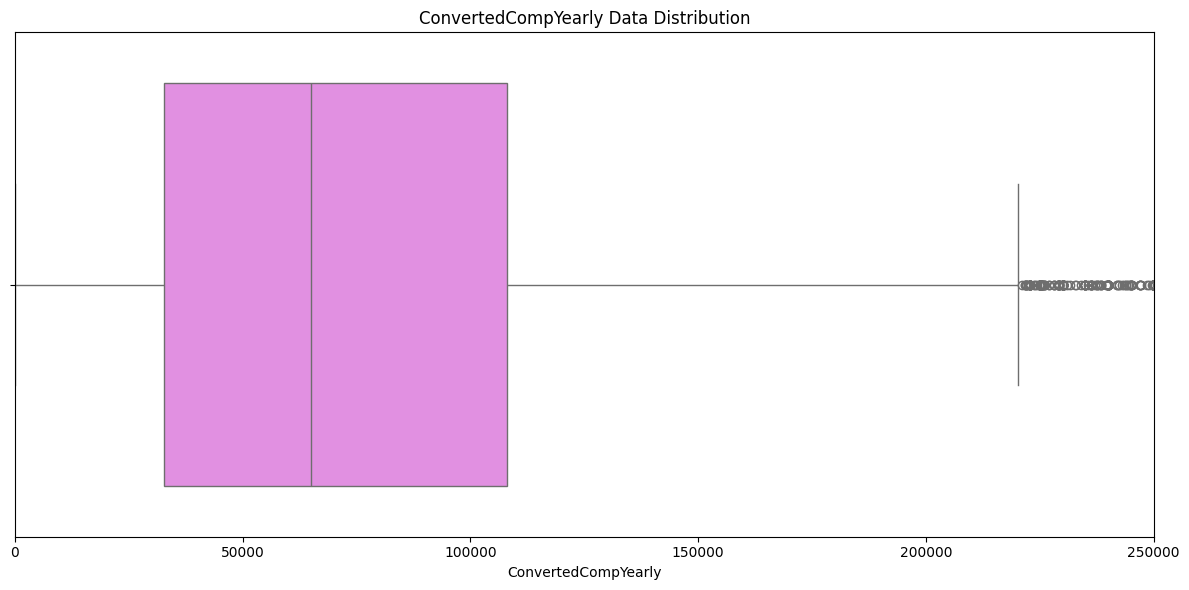

In [4]:
##Write your code here
Q1=df["ConvertedCompYearly"].quantile(.25)
Q3=df["ConvertedCompYearly"].quantile(.75)
IQR=Q3-Q1
print("Interquartile range=",IQR)
ub=Q3+1.5*IQR
lb=Q1-1.5*IQR
print(f"Lower bound= {0 if lb<0 else lb}\nUpper bound= {ub}")
count=len(df[df["ConvertedCompYearly"]>ub])
print(f"There are {count} outliers in the ConvertedCompYearly column.")
plt.figure(figsize=(12,6))
sns.boxplot(data=df,x="ConvertedCompYearly",color="violet")
plt.xlim(0,250000)
plt.title("ConvertedCompYearly Data Distribution")
plt.tight_layout()
plt.show()

<h3>Step 5: Remove Outliers and Create a New DataFrame</h3>


Remove outliers from the dataset.

- Create a new DataFrame excluding rows with outliers in `ConvertedCompYearly`.
- Validate the size of the new DataFrame.


In [5]:
##Write your code here
df1=df[df["ConvertedCompYearly"]<=ub]
if len(df["ConvertedCompYearly"].dropna())-len(df1)==count:
    print("Outliers in the ConvertedCompYearly column were removed successfully.")
else:
    print("Outliers in the ConvertedCompYearly column were not removed.")

Outliers in the ConvertedCompYearly column were removed successfully.


<h3>Step 6: Correlation Analysis</h3>


Analyze the correlation between `Age` (transformed) and other numerical columns.

- Map the `Age` column to approximate numeric values.

- Compute correlations between `Age` and other numeric variables.

- Visualize the correlation matrix.


C:\Users\21650\AppData\Local\Temp\ipykernel_3840\3517106965.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["Age"].replace(age_map,inplace=True)


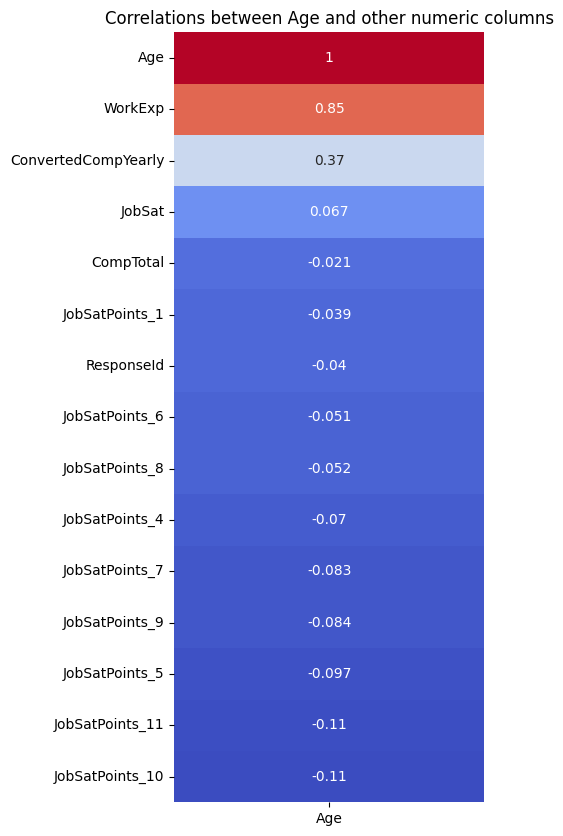

In [8]:
##Write your code here
import numpy as np
age_map={"Under 18 years old":18,
         "18-24 years old":21,
         "25-34 years old":29.5,
         "35-44 years old":39.5,
         "45-54 years old":49.5,
         "55-64 years old":59.5,
         "65 years or older":70,
         "Prefer not to say":np.nan}
df1["Age"].replace(age_map,inplace=True)
numeric_cols=df1.select_dtypes(include=['number']).columns
corr_age=df1[numeric_cols].corr()[["Age"]].sort_values("Age",ascending=False)
corr_age
plt.figure(figsize=(4,10))
sns.heatmap(corr_age,cmap='coolwarm',cbar=False,annot=True)
plt.title("Correlations between Age and other numeric columns")
plt.show()

In [9]:
df1["Age"].describe()

count    22449.000000
mean        33.974698
std          9.814633
min         18.000000
25%         29.500000
50%         29.500000
75%         39.500000
max         70.000000
Name: Age, dtype: float64

<h3> Summary </h3>


In this lab, you developed essential skills in **Exploratory Data Analysis (EDA)** with a focus on outlier detection and removal. Specifically, you:


- Loaded and explored the dataset to understand its structure.

- Analyzed the distribution of respondents across industries.

- Identified and removed high compensation outliers using statistical thresholds and the Interquartile Range (IQR) method.

- Performed correlation analysis, including transforming the `Age` column into numeric values for better analysis.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-1|1.1|Madhusudan Moole|Reviewed and updated lab|                                                                                    
|2024-09-29|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
